# Inverse dielectric versus $T^*$

Read the Majorana scan CSV files from `Data/` and plot $1/\epsilon_0$ with five-block sample-standard-deviation error bars. The dashed line is the universal KT line $1/\epsilon_0=4T^*$.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
})

In [3]:
# This works when Jupyter starts either inside 7.14 Majorana/ or at the repository root.
data_dir = Path("Data")
if not data_dir.is_dir():
    data_dir = Path("7.27 Majorana") / "Data"

csv_files = sorted(data_dir.glob("op_dielectric_E0_*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No op_dielectric_E0_*.csv files found in {data_dir.resolve()}")

required_columns = {
    "N",
    "rho_star",
    "T_star",
    "E0_star",
    "ϵ0_inv",
    "ϵ0_inv_block_std",
}

frames = []
for csv_file in csv_files:
    frame = pd.read_csv(csv_file)
    missing = required_columns.difference(frame.columns)
    if missing:
        raise ValueError(f"{csv_file.name} is missing columns: {sorted(missing)}")
    frame["source_file"] = csv_file.name
    frames.append(frame)

data = pd.concat(frames, ignore_index=True)
data = data.sort_values(["E0_star", "N", "rho_star", "T_star"]).reset_index(drop=True)

print(f"Loaded {len(data)} rows from {len(csv_files)} CSV file(s).")
data.groupby(["E0_star", "N", "rho_star"], as_index=False).agg(
    n_points=("T_star", "size"),
    T_min=("T_star", "min"),
    T_max=("T_star", "max"),
)

Loaded 561 rows from 11 CSV file(s).


,E0_star,N,rho_star,n_points,T_min,T_max
0,0.0,2,0.001,51,0.05,0.5
1,0.1,2,0.001,51,0.05,0.5
2,0.2,2,0.001,51,0.05,0.5
3,0.3,2,0.001,51,0.05,0.5
4,0.4,2,0.001,51,0.05,0.5
5,0.5,2,0.001,51,0.05,0.5
6,0.6,2,0.001,51,0.05,0.5
7,0.7,2,0.001,51,0.05,0.5
8,0.8,2,0.001,51,0.05,0.5
9,0.9,2,0.001,51,0.05,0.5


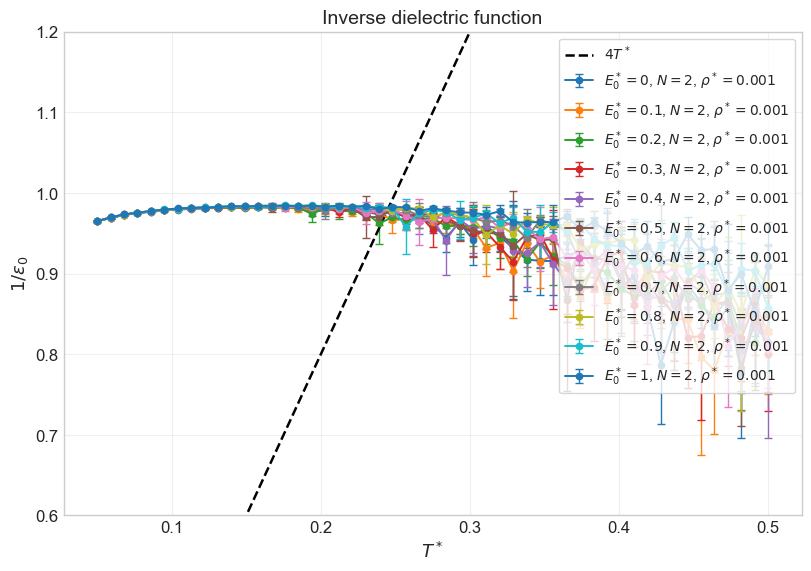

Saved figure to /Users/jinlingxiao123/Downloads/Research Project/BKT-plasma2D/7.27 Majorana/inverse_dielectric_vs_Tstar.png


In [9]:
fig, ax = plt.subplots(figsize=(8.0, 5.6), constrained_layout=True)

group_columns = ["E0_star", "N", "rho_star"]
for (E0_star, N, rho_star), group in data.groupby(group_columns, sort=True):
    group = group.sort_values("T_star")
    ax.errorbar(
        group["T_star"],
        group["ϵ0_inv"],
        yerr=group["ϵ0_inv_block_std"],
        fmt="o-",
        markersize=4.5,
        linewidth=1.4,
        elinewidth=1.0,
        capsize=3,
        capthick=1.0,
        label=rf"$E_0^*={E0_star:g}$, $N={int(N)}$, $\rho^*={rho_star:g}$",
    )

T_line = np.linspace(data["T_star"].min(), data["T_star"].max(), 500)
ax.plot(T_line, 4.0 * T_line, "k--", linewidth=1.8, label=r"$4T^*$")

ax.set_xlabel(r"$T^*$")
ax.set_ylabel(r"$1/\epsilon_0$")
ax.set_ylim(0.6, 1.2)
ax.set_title(r"Inverse dielectric function")
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)

output_path = data_dir.parent / "inverse_dielectric_vs_Tstar.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to {output_path.resolve()}")

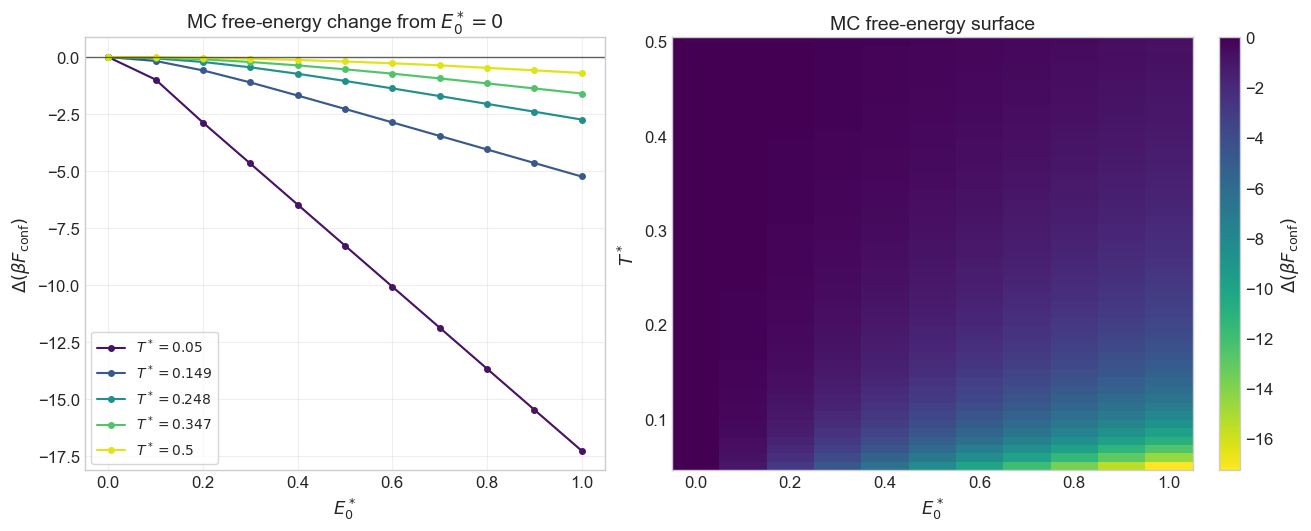

Saved figure to /Users/jinlingxiao123/Downloads/Research Project/BKT-plasma2D/7.27 Majorana/free_energy_vs_E0.png
Shaded bands are propagated five-block standard deviations.


,N,rho_star,T_star,E0_star,delta_beta_F,delta_beta_F_block_std
0,2,0.001,0.05,0.0,0.000000,0.000000
1,2,0.001,0.05,0.1,-0.986106,0.000998
2,2,0.001,0.05,0.2,-2.870715,0.002014
3,2,0.001,0.05,0.3,-4.668982,0.002373
4,2,0.001,0.05,0.4,-6.468265,0.003034
...,...,...,...,...,...,...
556,2,0.001,0.50,0.6,-0.271147,0.016455
557,2,0.001,0.50,0.7,-0.363224,0.019137
558,2,0.001,0.50,0.8,-0.470614,0.023104
559,2,0.001,0.50,0.9,-0.579907,0.025123


In [14]:
# MC relative configurational free energy from thermodynamic integration over E0*.
# The reference is Delta(beta F) = 0 at E0*=0 for every fixed T*.
free_energy_columns = {
    "d_betaF_d_E0_mean",
    "d_betaF_d_E0_block_std",
}
missing = free_energy_columns.difference(data.columns)
if missing:
    raise ValueError(f"Missing free-energy derivative columns: {sorted(missing)}")

system_ids = data[["N", "rho_star"]].drop_duplicates()
if len(system_ids) != 1:
    raise ValueError("The free-energy plot currently expects one (N, rho_star) system.")

def cumulative_simpson_operator(x):
    """Linear operator for cumulative Simpson integration on a uniform grid."""
    x = np.asarray(x, dtype=float)
    if len(x) < 3 or not np.all(np.diff(x) > 0):
        raise ValueError("Need at least three strictly increasing E0* points.")
    if not np.allclose(np.diff(x), np.diff(x)[0], rtol=1e-10, atol=1e-12):
        raise ValueError("Cumulative Simpson integration requires a uniform E0* grid.")

    operator = np.zeros((len(x), len(x)), dtype=float)
    for basis_index in range(len(x)):
        basis = np.zeros(len(x), dtype=float)
        basis[basis_index] = 1.0
        cumulative = np.zeros(len(x), dtype=float)

        for interval_index in range(len(x) - 1):
            h = x[interval_index + 1] - x[interval_index]
            if interval_index % 2 == 0 and interval_index + 2 < len(x):
                increment = h * (
                    5.0 * basis[interval_index]
                    + 8.0 * basis[interval_index + 1]
                    - basis[interval_index + 2]
                ) / 12.0
            elif interval_index % 2 == 1:
                increment = h * (
                    -basis[interval_index - 1]
                    + 8.0 * basis[interval_index]
                    + 5.0 * basis[interval_index + 1]
                ) / 12.0
            else:
                increment = 0.5 * h * (
                    basis[interval_index] + basis[interval_index + 1]
                )
            cumulative[interval_index + 1] = cumulative[interval_index] + increment

        operator[:, basis_index] = cumulative

    return operator

free_energy_frames = []
state_columns = ["N", "rho_star", "T_star"]
for _, group in data.groupby(state_columns, sort=True):
    group = group.sort_values("E0_star").reset_index(drop=True)
    E0_values = group["E0_star"].to_numpy(dtype=float)
    if not np.isclose(E0_values[0], 0.0):
        raise ValueError("Every T* group must include the E0*=0 reference state.")
    if group["E0_star"].duplicated().any():
        raise ValueError("Duplicate E0* values found within a fixed-T* group.")

    integration_operator = cumulative_simpson_operator(E0_values)
    derivative = group["d_betaF_d_E0_mean"].to_numpy(dtype=float)
    derivative_block_std = group["d_betaF_d_E0_block_std"].to_numpy(dtype=float)

    result = group[state_columns + ["E0_star"]].copy()
    result["delta_beta_F"] = integration_operator @ derivative
    result["delta_beta_F_block_std"] = np.sqrt(
        (integration_operator**2) @ (derivative_block_std**2)
    )
    free_energy_frames.append(result)

free_energy_data = pd.concat(free_energy_frames, ignore_index=True)

available_T = np.sort(free_energy_data["T_star"].unique())
target_T = [available_T[0], 0.149, 0.248, 0.347, available_T[-1]]
selected_T = sorted({
    float(available_T[np.argmin(np.abs(available_T - target))])
    for target in target_T
})

fig, (ax_curves, ax_surface) = plt.subplots(
    1, 2, figsize=(13.0, 5.2), constrained_layout=True
)
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(selected_T)))

for color, T_star in zip(colors, selected_T):
    group = free_energy_data[np.isclose(free_energy_data["T_star"], T_star)]
    group = group.sort_values("E0_star")
    x = group["E0_star"].to_numpy(dtype=float)
    y = group["delta_beta_F"].to_numpy(dtype=float)
    yerr = group["delta_beta_F_block_std"].to_numpy(dtype=float)
    ax_curves.plot(x, y, "o-", color=color, markersize=4, linewidth=1.5,
                   label=rf"$T^*={T_star:g}$")
    ax_curves.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.16)

ax_curves.axhline(0.0, color="black", linewidth=1.0, alpha=0.6)
ax_curves.set_xlabel(r"$E_0^*$")
ax_curves.set_ylabel(r"$\Delta(\beta F_{\mathrm{conf}})$")
ax_curves.set_title(r"MC free-energy change from $E_0^*=0$")
ax_curves.legend(frameon=True)
ax_curves.grid(True, alpha=0.3)

surface = free_energy_data.pivot(
    index="T_star", columns="E0_star", values="delta_beta_F"
).sort_index().sort_index(axis=1)
mesh = ax_surface.pcolormesh(
    surface.columns.to_numpy(dtype=float),
    surface.index.to_numpy(dtype=float),
    surface.to_numpy(dtype=float),
    shading="auto",
    cmap="viridis_r",
)
colorbar = fig.colorbar(mesh, ax=ax_surface)
colorbar.set_label(r"$\Delta(\beta F_{\mathrm{conf}})$")
ax_surface.set_xlabel(r"$E_0^*$")
ax_surface.set_ylabel(r"$T^*$")
ax_surface.set_title("MC free-energy surface")

free_energy_output_path = data_dir.parent / "free_energy_vs_E0.png"
fig.savefig(free_energy_output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure to {free_energy_output_path.resolve()}")
print("Shaded bands are propagated five-block standard deviations.")

free_energy_data


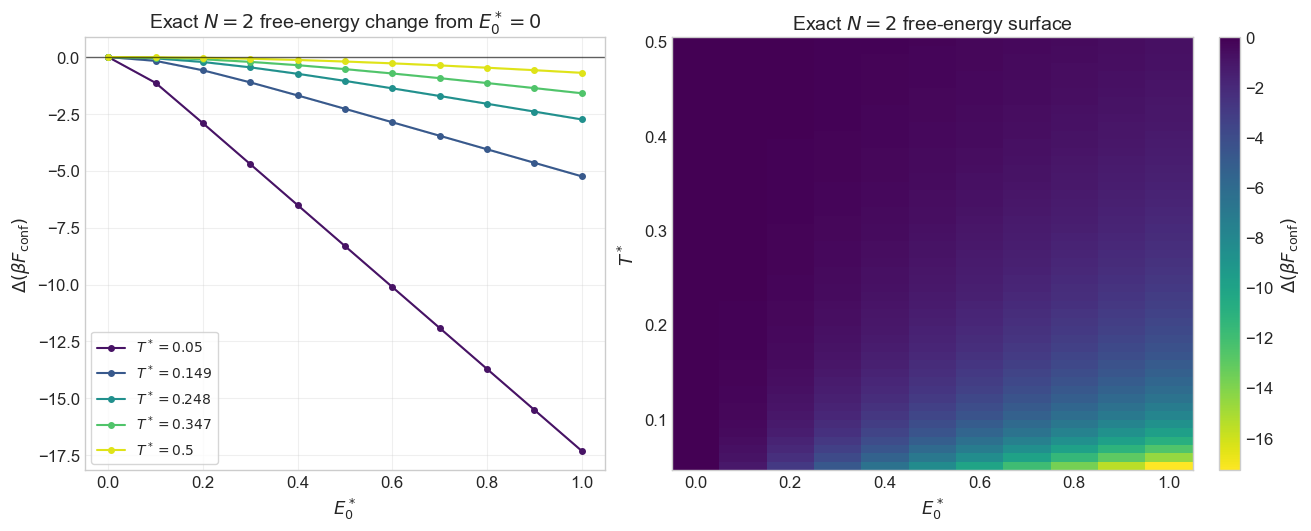

Loaded 561 exact states from /Users/jinlingxiao123/Downloads/Research Project/BKT-plasma2D/7.27 Majorana/Exact_N2/free_energy_all_states.csv
Saved figure to /Users/jinlingxiao123/Downloads/Research Project/BKT-plasma2D/7.27 Majorana/exact_free_energy_vs_E0.png
Shaded bands are |order 96 - order 64| quadrature differences.


,N,rho_star,T_star,kappa,E0_star,E0_over_T,a,xiF_over_xi,alpha,n_cut,...,beta_U_mean_exact,majorana_response_exact,d_betaF_d_kappa_exact,d_betaF_d_E0_exact,mean_abs_Q2_first_shell_exact,epsilon0_inv_exact,quadrature_relative_error_Q_conf,quadrature_error_beta_F_conf,quadrature_error_delta_beta_F,quadrature_error_epsilon0_inv
0,2,0.001,0.05,20.0,0.0,0.0,0.022361,10.0,1.772454,1,...,-74.899919,0.000000,-3.744996,-0.000000,0.011085,0.964715,1.380049e-14,1.421085e-14,0.000000e+00,0.000000e+00
1,2,0.001,0.05,20.0,0.1,2.0,0.022361,10.0,1.772454,1,...,-76.044516,0.851685,-3.830740,-17.033710,0.011071,0.964761,8.235420e-15,0.000000e+00,1.421085e-14,0.000000e+00
2,2,0.001,0.05,20.0,0.2,4.0,0.022361,10.0,1.772454,1,...,-77.830235,0.898332,-3.925862,-17.966630,0.011055,0.964810,1.083284e-14,1.421085e-14,0.000000e+00,2.220446e-16
3,2,0.001,0.05,20.0,0.3,6.0,0.022361,10.0,1.772454,1,...,-79.640842,0.899700,-4.016687,-17.993992,0.011041,0.964856,1.258046e-14,1.421085e-14,0.000000e+00,1.110223e-16
4,2,0.001,0.05,20.0,0.4,8.0,0.022361,10.0,1.772454,1,...,-81.452074,0.899792,-4.107261,-17.995841,0.011027,0.964901,9.488893e-15,0.000000e+00,1.421085e-14,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,2,0.001,0.50,2.0,0.6,1.2,0.022361,10.0,1.772454,1,...,-5.126728,0.429275,-2.676598,-0.858550,0.477210,0.848099,1.573098e-16,4.440892e-16,3.552714e-15,6.661338e-16
557,2,0.001,0.50,2.0,0.7,1.4,0.022361,10.0,1.772454,1,...,-5.313729,0.479896,-2.798568,-0.959791,0.447558,0.857538,3.303317e-15,3.108624e-15,7.105427e-15,4.440892e-16
558,2,0.001,0.50,2.0,0.8,1.6,0.022361,10.0,1.772454,1,...,-5.514995,0.524003,-2.926554,-1.048006,0.417493,0.867108,7.403770e-15,7.105427e-15,1.110223e-14,7.771561e-16
559,2,0.001,0.50,2.0,0.9,1.8,0.022361,10.0,1.772454,1,...,-5.726890,0.562103,-3.057932,-1.124205,0.387830,0.876550,2.679758e-15,2.664535e-15,6.661338e-15,6.661338e-16


In [15]:
# Exact N=2 relative configurational free energy from deterministic quadrature.
# This cell is independent of the Monte Carlo thermodynamic-integration result above.
exact_csv_path = Path("Exact_N2") / "free_energy_all_states.csv"
if not exact_csv_path.is_file():
    exact_csv_path = Path("7.27 Majorana") / "Exact_N2" / "free_energy_all_states.csv"
if not exact_csv_path.is_file():
    raise FileNotFoundError(
        f"Could not find Exact_N2/free_energy_all_states.csv from {Path.cwd()}"
    )

exact_required_columns = {
    "N",
    "rho_star",
    "T_star",
    "E0_star",
    "delta_beta_F_exact",
    "quadrature_error_delta_beta_F",
}
exact_free_energy_data = pd.read_csv(exact_csv_path)
missing = exact_required_columns.difference(exact_free_energy_data.columns)
if missing:
    raise ValueError(f"Exact free-energy CSV is missing columns: {sorted(missing)}")

exact_free_energy_data = exact_free_energy_data.sort_values(
    ["N", "rho_star", "T_star", "E0_star"]
).reset_index(drop=True)
if exact_free_energy_data[["N", "rho_star"]].drop_duplicates().shape[0] != 1:
    raise ValueError("The exact free-energy plot currently expects one (N, rho_star) system.")
if exact_free_energy_data.duplicated(["N", "rho_star", "T_star", "E0_star"]).any():
    raise ValueError("Duplicate exact states found in the CSV.")

exact_reference = exact_free_energy_data[np.isclose(exact_free_energy_data["E0_star"], 0.0)]
n_temperatures = exact_free_energy_data["T_star"].nunique()
if len(exact_reference) != n_temperatures:
    raise ValueError("Every exact T* group must include the E0*=0 reference state.")
if not np.allclose(exact_reference["delta_beta_F_exact"], 0.0, atol=1e-12):
    raise ValueError("Exact delta_beta_F must be zero at E0*=0.")

available_exact_T = np.sort(exact_free_energy_data["T_star"].unique())
target_exact_T = [
    available_exact_T[0], 0.149, 0.248, 0.347, available_exact_T[-1]
]
selected_exact_T = sorted({
    float(available_exact_T[np.argmin(np.abs(available_exact_T - target))])
    for target in target_exact_T
})

fig, (ax_exact_curves, ax_exact_surface) = plt.subplots(
    1, 2, figsize=(13.0, 5.2), constrained_layout=True
)
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(selected_exact_T)))

for color, T_star in zip(colors, selected_exact_T):
    group = exact_free_energy_data[
        np.isclose(exact_free_energy_data["T_star"], T_star)
    ].sort_values("E0_star")
    x = group["E0_star"].to_numpy(dtype=float)
    y = group["delta_beta_F_exact"].to_numpy(dtype=float)
    yerr = group["quadrature_error_delta_beta_F"].to_numpy(dtype=float)
    ax_exact_curves.plot(
        x, y, "o-", color=color, markersize=4, linewidth=1.5,
        label=rf"$T^*={T_star:g}$",
    )
    ax_exact_curves.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.16)

ax_exact_curves.axhline(0.0, color="black", linewidth=1.0, alpha=0.6)
ax_exact_curves.set_xlabel(r"$E_0^*$")
ax_exact_curves.set_ylabel(r"$\Delta(\beta F_{\mathrm{conf}})$")
ax_exact_curves.set_title(r"Exact $N=2$ free-energy change from $E_0^*=0$")
ax_exact_curves.legend(frameon=True)
ax_exact_curves.grid(True, alpha=0.3)

exact_surface = exact_free_energy_data.pivot(
    index="T_star", columns="E0_star", values="delta_beta_F_exact"
).sort_index().sort_index(axis=1)
exact_mesh = ax_exact_surface.pcolormesh(
    exact_surface.columns.to_numpy(dtype=float),
    exact_surface.index.to_numpy(dtype=float),
    exact_surface.to_numpy(dtype=float),
    shading="auto",
    cmap="viridis_r",
)
exact_colorbar = fig.colorbar(exact_mesh, ax=ax_exact_surface)
exact_colorbar.set_label(r"$\Delta(\beta F_{\mathrm{conf}})$")
ax_exact_surface.set_xlabel(r"$E_0^*$")
ax_exact_surface.set_ylabel(r"$T^*$")
ax_exact_surface.set_title(r"Exact $N=2$ free-energy surface")

exact_free_energy_output_path = exact_csv_path.parent.parent / "exact_free_energy_vs_E0.png"
fig.savefig(exact_free_energy_output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Loaded {len(exact_free_energy_data)} exact states from {exact_csv_path.resolve()}")
print(f"Saved figure to {exact_free_energy_output_path.resolve()}")
print("Shaded bands are |order 96 - order 64| quadrature differences.")

exact_free_energy_data


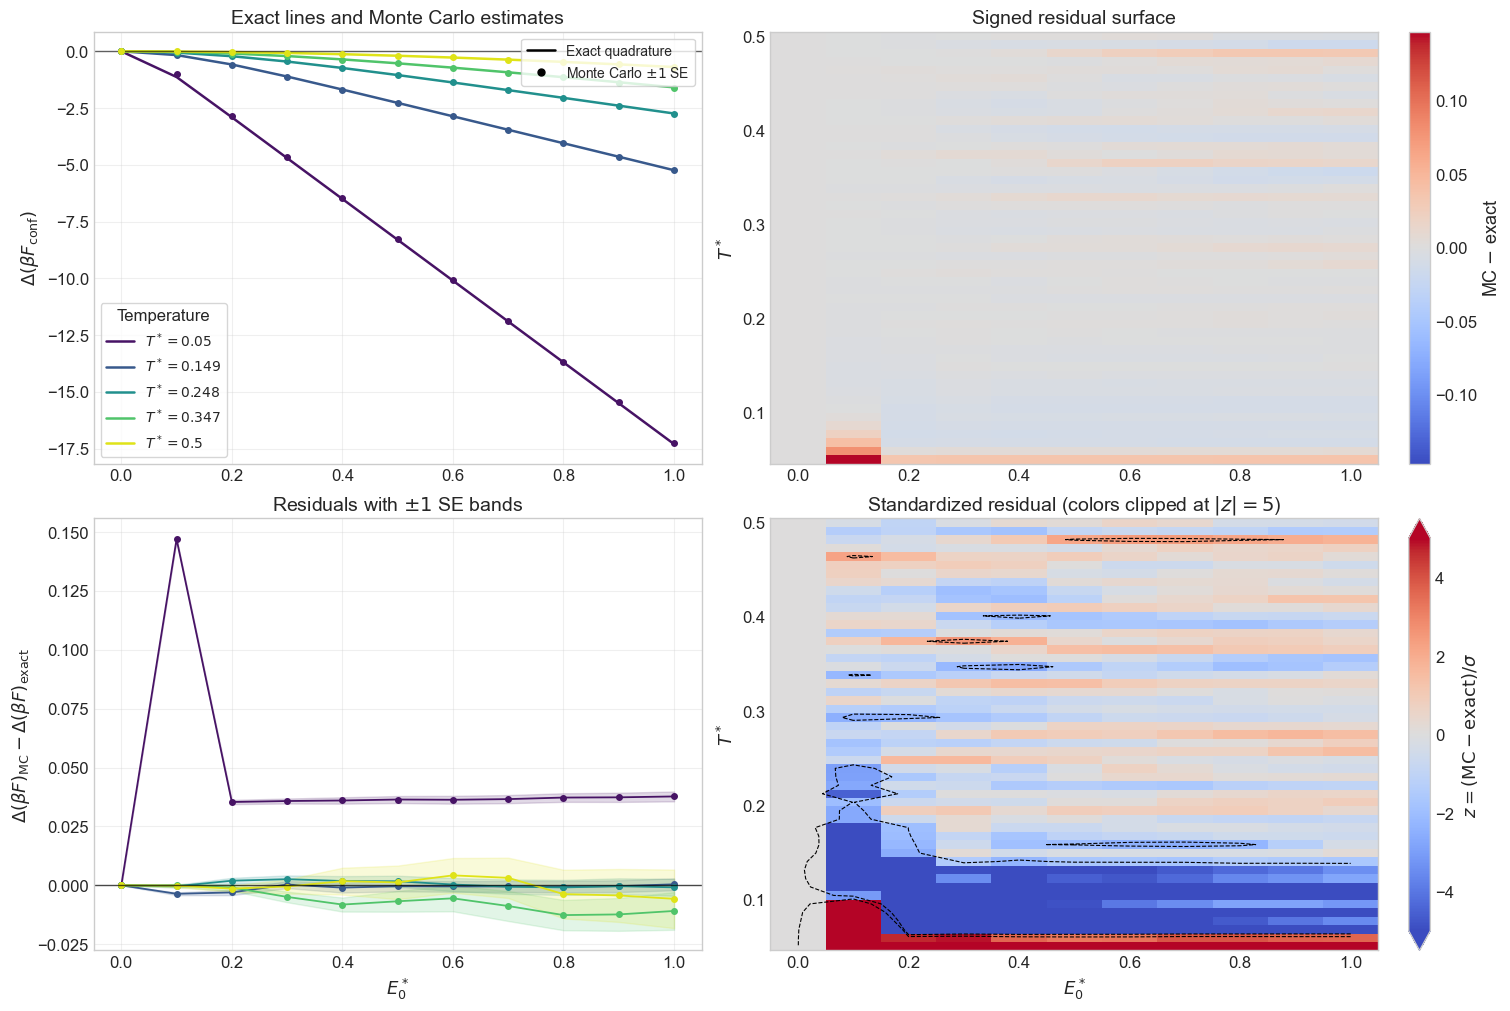

Compared 561 matched states.
RMSE excluding E0*=0: 0.0110307
Maximum absolute residual: 0.146928
Fraction within 2 SE: 73.9%
Saved figure to /Users/jinlingxiao123/Downloads/Research Project/BKT-plasma2D/7.27 Majorana/mc_vs_exact_free_energy.png


,T_star,rmse,max_abs_residual,max_abs_z
0,0.050,0.057969,0.146928,329.242862
1,0.059,0.025625,0.079216,232.232938
2,0.068,0.016364,0.041864,124.970571
3,0.077,0.011566,0.020957,39.744742
4,0.086,0.009994,0.011217,23.636848
5,0.095,0.006642,0.009556,12.991975
6,0.104,0.008885,0.009837,13.500742
7,0.113,0.008017,0.009641,15.087179
8,0.122,0.004705,0.005991,14.437578
9,0.131,0.005226,0.006287,17.123610


In [16]:
# Point-by-point comparison of Monte Carlo and exact N=2 free energies.
# Residual convention: MC - exact. Positive values mean that MC is less negative.
from matplotlib.lines import Line2D

comparison_keys = ["N", "rho_star", "T_star", "E0_star"]
mc_comparison_columns = comparison_keys + [
    "delta_beta_F",
    "delta_beta_F_block_std",
]
exact_comparison_columns = comparison_keys + [
    "delta_beta_F_exact",
    "quadrature_error_delta_beta_F",
]

block_counts = data[comparison_keys + ["n_blocks"]].copy()
if block_counts.groupby(comparison_keys)["n_blocks"].nunique().max() != 1:
    raise ValueError("Inconsistent n_blocks values within an MC state.")
block_counts = block_counts.drop_duplicates(comparison_keys)
if (block_counts["n_blocks"] < 2).any():
    raise ValueError("At least two blocks are required for a standard error.")

comparison_data = free_energy_data[mc_comparison_columns].merge(
    exact_free_energy_data[exact_comparison_columns],
    on=comparison_keys,
    how="outer",
    validate="one_to_one",
    indicator=True,
)
unmatched = comparison_data[comparison_data["_merge"] != "both"]
if not unmatched.empty:
    raise ValueError(
        f"MC and exact parameter grids do not match at {len(unmatched)} state(s)."
    )
comparison_data = comparison_data.drop(columns="_merge").merge(
    block_counts,
    on=comparison_keys,
    how="left",
    validate="one_to_one",
).sort_values(comparison_keys).reset_index(drop=True)

# delta_beta_F_block_std is the propagated SD of the block means.
# Divide by sqrt(n_blocks) to estimate the standard error of the MC mean.
comparison_data["delta_beta_F_mc_se"] = (
    comparison_data["delta_beta_F_block_std"]
    / np.sqrt(comparison_data["n_blocks"])
)
comparison_data["residual_mc_minus_exact"] = (
    comparison_data["delta_beta_F"]
    - comparison_data["delta_beta_F_exact"]
)
comparison_data["residual_se"] = np.hypot(
    comparison_data["delta_beta_F_mc_se"],
    comparison_data["quadrature_error_delta_beta_F"],
)

residual = comparison_data["residual_mc_minus_exact"].to_numpy(dtype=float)
residual_se = comparison_data["residual_se"].to_numpy(dtype=float)
nonzero_uncertainty = residual_se > 0.0
z_score = np.full(len(comparison_data), np.nan, dtype=float)
z_score[nonzero_uncertainty] = (
    residual[nonzero_uncertainty] / residual_se[nonzero_uncertainty]
)
zero_reference = (~nonzero_uncertainty) & np.isclose(residual, 0.0, atol=1e-14)
z_score[zero_reference] = 0.0
if np.any((~nonzero_uncertainty) & (~zero_reference)):
    raise ValueError("A nonzero residual has zero estimated uncertainty.")
comparison_data["z_score"] = z_score

available_comparison_T = np.sort(comparison_data["T_star"].unique())
target_comparison_T = [
    available_comparison_T[0], 0.149, 0.248, 0.347, available_comparison_T[-1]
]
selected_comparison_T = sorted({
    float(available_comparison_T[np.argmin(np.abs(available_comparison_T - target))])
    for target in target_comparison_T
})

fig = plt.figure(figsize=(15.0, 10.0), constrained_layout=True)
grid = fig.add_gridspec(2, 2)
ax_overlay = fig.add_subplot(grid[0, 0])
ax_residual = fig.add_subplot(grid[1, 0], sharex=ax_overlay)
ax_residual_heatmap = fig.add_subplot(grid[0, 1])
ax_z_heatmap = fig.add_subplot(grid[1, 1], sharex=ax_residual_heatmap,
                               sharey=ax_residual_heatmap)
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(selected_comparison_T)))

for color, T_star in zip(colors, selected_comparison_T):
    group = comparison_data[
        np.isclose(comparison_data["T_star"], T_star)
    ].sort_values("E0_star")
    x = group["E0_star"].to_numpy(dtype=float)
    exact_y = group["delta_beta_F_exact"].to_numpy(dtype=float)
    mc_y = group["delta_beta_F"].to_numpy(dtype=float)
    mc_se = group["delta_beta_F_mc_se"].to_numpy(dtype=float)
    residual_y = group["residual_mc_minus_exact"].to_numpy(dtype=float)
    residual_yerr = group["residual_se"].to_numpy(dtype=float)

    ax_overlay.plot(
        x, exact_y, color=color, linewidth=1.8, label=rf"$T^*={T_star:g}$"
    )
    ax_overlay.errorbar(
        x, mc_y, yerr=mc_se, fmt="o", color=color, markersize=4,
        capsize=2, linewidth=1.0, label="_nolegend_",
    )
    ax_residual.plot(x, residual_y, "o-", color=color, markersize=4,
                     linewidth=1.3)
    ax_residual.fill_between(
        x, residual_y - residual_yerr, residual_y + residual_yerr,
        color=color, alpha=0.16,
    )

temperature_legend = ax_overlay.legend(title="Temperature", loc="lower left",
                                       frameon=True)
ax_overlay.add_artist(temperature_legend)
method_handles = [
    Line2D([0], [0], color="black", linewidth=1.8, label="Exact quadrature"),
    Line2D([0], [0], color="black", marker="o", linestyle="none",
           markersize=5, label=r"Monte Carlo $\pm1$ SE"),
]
ax_overlay.legend(handles=method_handles, loc="upper right", frameon=True)
ax_overlay.axhline(0.0, color="black", linewidth=1.0, alpha=0.6)
ax_overlay.set_ylabel(r"$\Delta(\beta F_{\mathrm{conf}})$")
ax_overlay.set_title(r"Exact lines and Monte Carlo estimates")
ax_overlay.grid(True, alpha=0.3)

ax_residual.axhline(0.0, color="black", linewidth=1.0, alpha=0.7)
ax_residual.set_xlabel(r"$E_0^*$")
ax_residual.set_ylabel(r"$\Delta(\beta F)_{\mathrm{MC}}-\Delta(\beta F)_{\mathrm{exact}}$")
ax_residual.set_title(r"Residuals with $\pm1$ SE bands")
ax_residual.grid(True, alpha=0.3)

residual_surface = comparison_data.pivot(
    index="T_star", columns="E0_star", values="residual_mc_minus_exact"
).sort_index().sort_index(axis=1)
residual_limit = max(
    float(np.nanmax(np.abs(residual_surface.to_numpy(dtype=float)))),
    np.finfo(float).eps,
)
residual_mesh = ax_residual_heatmap.pcolormesh(
    residual_surface.columns.to_numpy(dtype=float),
    residual_surface.index.to_numpy(dtype=float),
    residual_surface.to_numpy(dtype=float),
    shading="auto", cmap="coolwarm", vmin=-residual_limit, vmax=residual_limit,
)
residual_colorbar = fig.colorbar(residual_mesh, ax=ax_residual_heatmap)
residual_colorbar.set_label(r"MC $-$ exact")
ax_residual_heatmap.set_ylabel(r"$T^*$")
ax_residual_heatmap.set_title("Signed residual surface")

z_surface = comparison_data.pivot(
    index="T_star", columns="E0_star", values="z_score"
).sort_index().sort_index(axis=1)
z_values = z_surface.to_numpy(dtype=float)
# Clip only the displayed color range so isolated very large z-scores do not
# wash out the scientifically useful |z|=1--5 structure. Raw values are unchanged.
z_limit = 5.0
z_mesh = ax_z_heatmap.pcolormesh(
    z_surface.columns.to_numpy(dtype=float),
    z_surface.index.to_numpy(dtype=float),
    z_values,
    shading="auto", cmap="coolwarm", vmin=-z_limit, vmax=z_limit,
)
z_min = float(np.nanmin(z_values))
z_max = float(np.nanmax(z_values))
contour_levels = [level for level in (-2.0, 2.0) if z_min < level < z_max]
if contour_levels:
    ax_z_heatmap.contour(
        z_surface.columns.to_numpy(dtype=float),
        z_surface.index.to_numpy(dtype=float),
        z_values,
        levels=contour_levels,
        colors="black",
        linewidths=0.8,
        linestyles="--",
    )
z_colorbar = fig.colorbar(z_mesh, ax=ax_z_heatmap, extend="both")
z_colorbar.set_label(r"$z=(\mathrm{MC}-\mathrm{exact})/\sigma$")
ax_z_heatmap.set_xlabel(r"$E_0^*$")
ax_z_heatmap.set_ylabel(r"$T^*$")
ax_z_heatmap.set_title(r"Standardized residual (colors clipped at $|z|=5$)")

comparison_output_path = data_dir.parent / "mc_vs_exact_free_energy.png"
fig.savefig(comparison_output_path, dpi=300, bbox_inches="tight")
plt.show()

non_reference = ~np.isclose(comparison_data["E0_star"], 0.0)
comparison_non_reference = comparison_data[non_reference]
rmse = np.sqrt(np.mean(comparison_non_reference["residual_mc_minus_exact"] ** 2))
max_abs_residual = comparison_non_reference["residual_mc_minus_exact"].abs().max()
within_two_se = np.mean(comparison_non_reference["z_score"].abs() <= 2.0)
print(f"Compared {len(comparison_data)} matched states.")
print(f"RMSE excluding E0*=0: {rmse:.6g}")
print(f"Maximum absolute residual: {max_abs_residual:.6g}")
print(f"Fraction within 2 SE: {within_two_se:.1%}")
print(f"Saved figure to {comparison_output_path.resolve()}")

comparison_summary = comparison_non_reference.groupby("T_star", as_index=False).agg(
    rmse=("residual_mc_minus_exact", lambda values: np.sqrt(np.mean(values**2))),
    max_abs_residual=("residual_mc_minus_exact", lambda values: np.max(np.abs(values))),
    max_abs_z=("z_score", lambda values: np.max(np.abs(values))),
)
comparison_summary
